# Loan Default Risk: Data Cleaning & Exploratory Analysis

**Tools:** Python (pandas, matplotlib, seaborn)
**Dataset:** ~32,600 anonymized personal loan applications (customer demographics, loan terms, credit history, and current default status)

## Overview

This notebook cleans and explores a raw loan-level dataset to understand what actually drives default risk. The focus is not just on producing charts, but on treating every step of the cleaning process as a decision worth documenting — several of the "obvious" fixes turned out to be wrong, and the most useful finding in the whole analysis came from questioning *why* data was missing rather than just filling it in.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

In [ ]:
df = pd.read_csv("LoanData.csv")
print(df.shape)
df.head(3)

(32586, 13)


In [ ]:
df.info()
df.isnull().sum()

customer_id                3
customer_age                0
customer_income             0
home_ownership               0
employment_duration        895
loan_intent                  0
loan_grade                   0
loan_amnt                    1
loan_int_rate              3116
term_years                   0
historical_default        20737
cred_hist_length             0
Current_loan_status          4
dtype: int64

In [ ]:
df['loan_amnt'] = df['loan_amnt'].str.replace('£', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['customer_income'] = df['customer_income'].str.replace(',', '', regex=False).astype(float)

In [ ]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

Dropped 6 exact duplicate rows

In [ ]:
before = len(df)
df = df.dropna(subset=['Current_loan_status'])
print(f"Dropped {before - len(df)} rows with missing target")

Dropped 4 rows with missing target

In [ ]:
before = len(df)
df = df[(df['customer_age'] >= 18) & (df['customer_age'] <= 100)]
df = df[(df['employment_duration'].isna()) | (df['employment_duration'] < (df['customer_age'] - 14))]
print(f"Dropped {before - len(df)} rows with implausible age / employment combinations")

Dropped 10 rows with implausible age / employment_duration combinations

In [ ]:
before = len(df)
df = df[df['customer_income'] <= 500000]
df = df[df['loan_amnt'] <= 100000]
print(f"Dropped {before - len(df)} extreme income/loan_amnt outliers")

Dropped 55 rows with extreme income/loan_amnt outliers (likely data entry errors)

In [ ]:
df['historical_default'] = df['historical_default'].fillna('Unknown')

In [ ]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()

customer_id              3
customer_age             0
customer_income          0
home_ownership            0
employment_duration    894
loan_intent               0
loan_grade                0
loan_amnt                 0
loan_int_rate             0
term_years                0
historical_default        0
cred_hist_length          0
Current_loan_status       0
dtype: int64

In [ ]:
df['loan_to_income'] = df['loan_amnt'] / df['customer_income']
overall_default_rate = (df['Current_loan_status'] == 'DEFAULT').mean()
print(f"Overall default rate: {overall_default_rate:.1%}")

Overall default rate: 21.0%

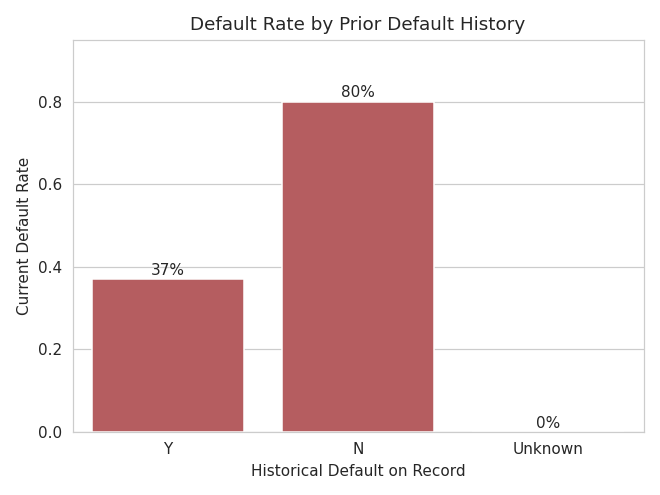

In [ ]:
hist_default = df.groupby('historical_default')['Current_loan_status'] \
    .apply(lambda x: (x == 'DEFAULT').mean()).reindex(['Y','N','Unknown'])

plt.figure(figsize=(6,4.5))
ax = sns.barplot(x=hist_default.index, y=hist_default.values, color="#C44E52")
for i, v in enumerate(hist_default.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha='center', fontsize=10)
plt.title("Default Rate by Prior Default History")
plt.xlabel("Historical Default on Record")
plt.ylabel("Current Default Rate")
plt.ylim(0, hist_default.max() + 0.15)
plt.tight_layout()
plt.show()

### Loan grade

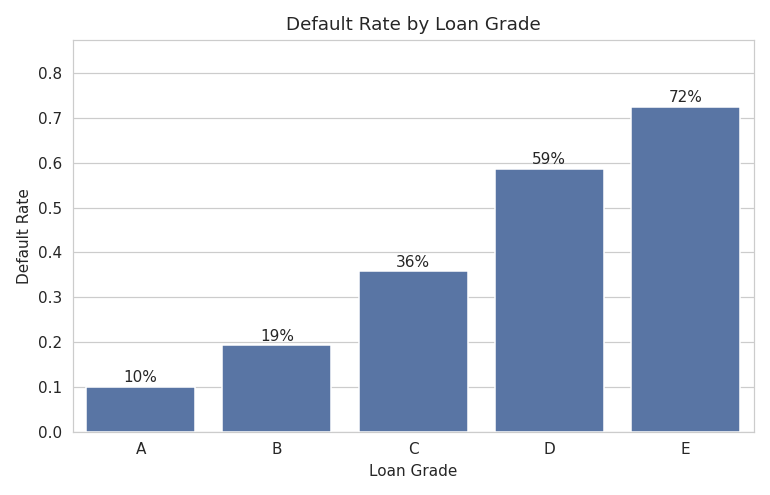

In [ ]:
grade_default = df.groupby('loan_grade')['Current_loan_status'].apply(lambda x: (x == 'DEFAULT').mean()).sort_index()

plt.figure(figsize=(7,4.5))
ax = sns.barplot(x=grade_default.index, y=grade_default.values, color="#4C72B0")
for i, v in enumerate(grade_default.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha='center', fontsize=10)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.ylim(0, grade_default.max() + 0.15)
plt.tight_layout()
plt.show()

### Loan purpose

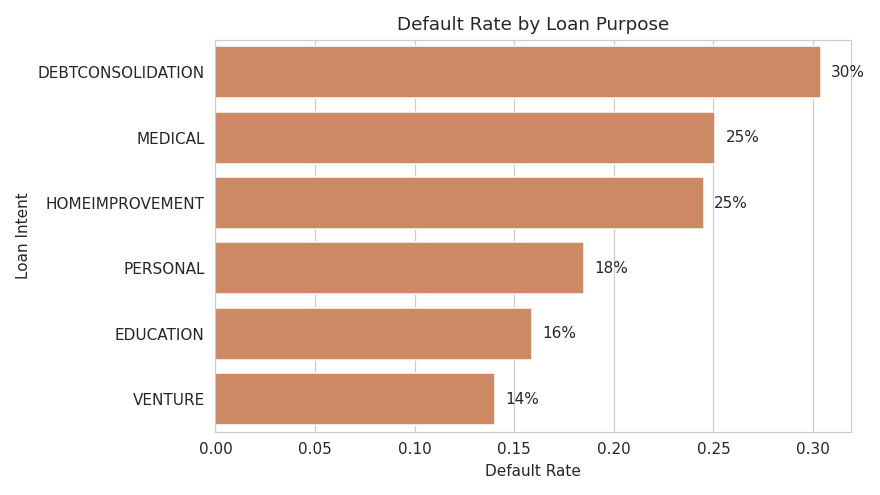

In [ ]:
intent_default = df.groupby('loan_intent')['Current_loan_status'].apply(lambda x: (x == 'DEFAULT').mean()).sort_values(ascending=False)

plt.figure(figsize=(8,4.5))
ax = sns.barplot(x=intent_default.values, y=intent_default.index, color="#DD8452")
for i, v in enumerate(intent_default.values):
    ax.text(v + 0.005, i, f"{v:.0%}", va='center', fontsize=10)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate")
plt.ylabel("Loan Intent")
plt.tight_layout()
plt.show()

Debt consolidation loans default most often (30%) — arguably unsurprising, since these are taken out by applicants already managing existing debt. Venture and education loans default least (14-16%).

### Home ownership

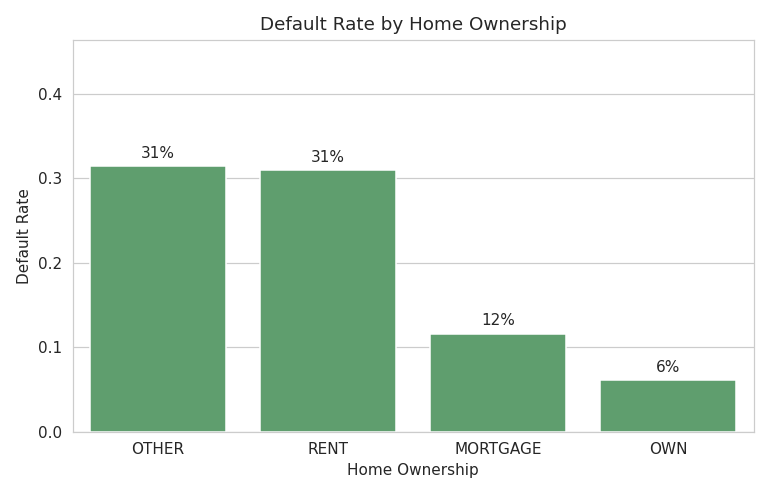

In [ ]:
home_default = df.groupby('home_ownership')['Current_loan_status'].apply(lambda x: (x == 'DEFAULT').mean()).sort_values(ascending=False)

plt.figure(figsize=(7,4.5))
ax = sns.barplot(x=home_default.index, y=home_default.values, color="#55A868")
for i, v in enumerate(home_default.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha='center', fontsize=10)
plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate")
plt.ylim(0, home_default.max() + 0.15)
plt.tight_layout()
plt.show()

Renters default at roughly 5x the rate of homeowners (31% vs. 6%) — likely a proxy for overall financial stability rather than a causal effect of renting itself.

### Interest rate and loan-to-income ratio

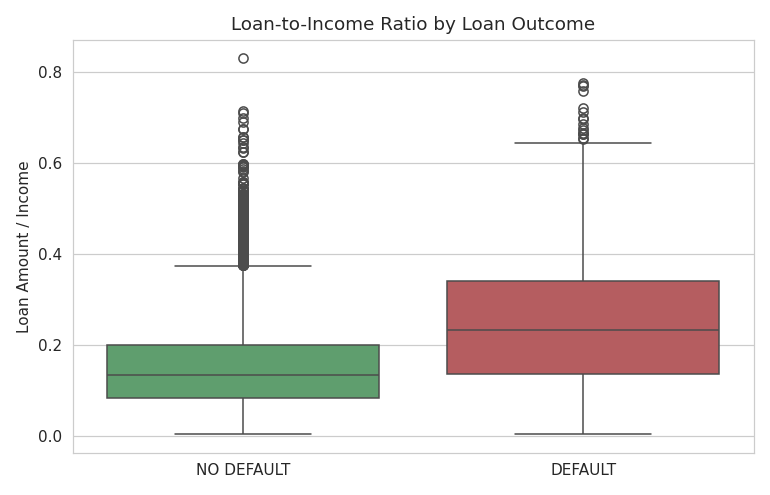

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.boxplot(data=df, x='Current_loan_status', y='loan_int_rate', ax=axes[0])
axes[0].set_title("Interest Rate by Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("Interest Rate (%)")

sns.boxplot(data=df[df['loan_to_income'] < 1.5], x='Current_loan_status', y='loan_to_income', ax=axes[1])
axes[1].set_title("Loan-to-Income Ratio by Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Loan Amount / Income")
plt.tight_layout()
plt.show()

### Income vs. loan amount

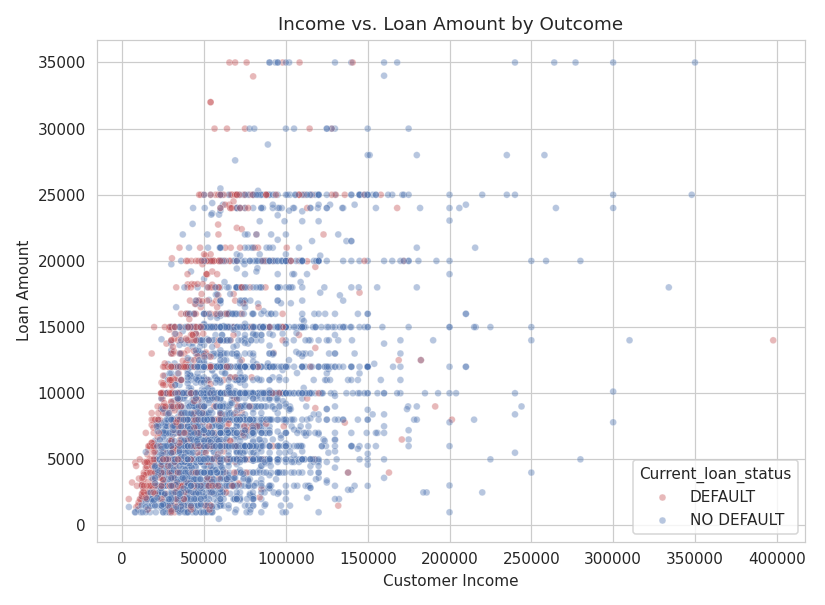

In [ ]:
sample = df.sample(min(4000, len(df)), random_state=1)
plt.figure(figsize=(7.5,5.5))
sns.scatterplot(data=sample, x='customer_income', y='loan_amnt', hue='Current_loan_status',
                 alpha=0.4, palette={"DEFAULT":"#C44E52","NO DEFAULT":"#4C72B0"}, s=20)
plt.title("Income vs. Loan Amount by Outcome")
plt.xlabel("Customer Income")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

##**Key findings**

Loan grade is the strongest predictor of default — a clean, monotonic climb from 10% (Grade A) to 72% (Grade E).

Historical_default's missingness is not random and likely leaks the target — every "Unknown" row is NO DEFAULT; this field needs a data-governance conversation before it's used in any model, not just an imputation strategy.
Renters default ~5x more often than homeowners (31% vs. 6%), and debt consolidation loans default most by purpose (30%) — both plausible proxies for existing financial strain.
Loan-to-income ratio and interest rate both move with default risk in the expected direction, and combined with grade, would likely form the core of a simple risk-scoring model.
Data quality issues were substantial and non-random: currency-formatted fields, 6 exact duplicates, ages up to 144, employment histories exceeding applicants' ages, and income/loan values in the millions — none of which would be caught by a quick .describe() alone without checking distributions and cross-field logic.
Next steps
A natural extension of this notebook is a simple logistic regression or decision tree using grade, loan-to-income ratio, interest rate, and home ownership (explicitly excluding historical_default given the leakage risk identified above), to see how much predictive power those "clean" fields carry on their own.

